In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "../data/processed/demand_weather_merged.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

In [4]:
df.head()

,forecast_MW,demand_MW,temperature
timestamp,,,
2018-01-01 00:00:00,45764.0,50863.0,8.3
2018-01-01 01:00:00,47834.0,50587.0,7.8
2018-01-01 02:00:00,48313.0,50650.0,7.1
2018-01-01 03:00:00,49513.0,50737.0,6.2
2018-01-01 04:00:00,48663.0,51021.0,4.8


In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 52584 entries, 2018-01-01 00:00:00 to 2023-12-31 23:00:00
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   forecast_MW  52584 non-null  float64
 1   demand_MW    52584 non-null  float64
 2   temperature  52584 non-null  float64
dtypes: float64(3)
memory usage: 1.6 MB


In [6]:
df.describe()

,forecast_MW,demand_MW,temperature
count,52584.000000,52584.000000,52584.000000
mean,46033.037825,45857.592538,21.039413
std,10826.467471,10576.296820,7.674092
min,26391.000000,27371.000000,-10.900000
25%,38319.000000,38301.750000,16.000000
50%,43278.500000,43285.000000,22.500000
75%,51607.500000,51307.750000,26.500000
max,86895.000000,85432.000000,41.700000


In [7]:
# drop forecast_MW column as it is not a feature we will use for modeling
df.drop(columns=["forecast_MW"], inplace=True)

In [8]:
# Extracting time-based features
df['hour_of_day'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['time_of_day'] =  pd.cut(
    df["hour_of_day"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    right=False
)
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df.head()

,demand_MW,temperature,hour_of_day,day_of_week,time_of_day,month,is_weekend
timestamp,,,,,,,
2018-01-01 00:00:00,50863.0,8.3,0,0,Night,1,0
2018-01-01 01:00:00,50587.0,7.8,1,0,Night,1,0
2018-01-01 02:00:00,50650.0,7.1,2,0,Night,1,0
2018-01-01 03:00:00,50737.0,6.2,3,0,Night,1,0
2018-01-01 04:00:00,51021.0,4.8,4,0,Night,1,0


<Figure size 1000x600 with 0 Axes>

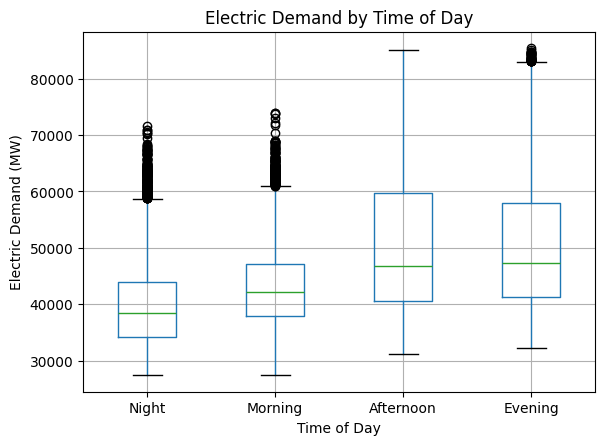

In [9]:
# Visualize the distribution of demand across different times of the day
plt.figure(figsize=(10, 6))
df.boxplot(column='demand_MW', by='time_of_day')
plt.title('Electric Demand by Time of Day')
plt.suptitle('')
plt.xlabel('Time of Day')
plt.ylabel('Electric Demand (MW)')
plt.show()

<Figure size 1000x600 with 0 Axes>

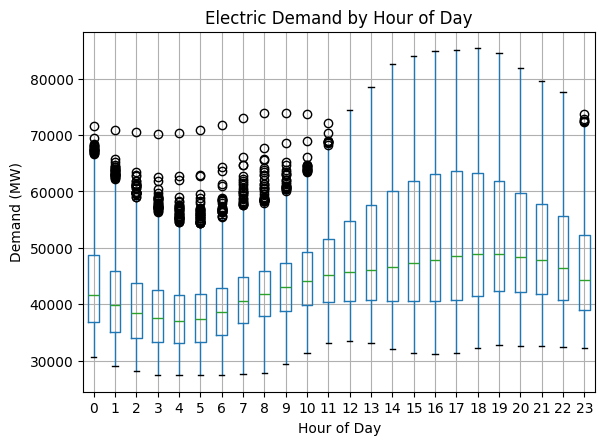

In [17]:
# Visualize the distribution of demand across different hours of the day
plt.figure(figsize=(10,6))
df.boxplot(column='demand_MW', by='hour_of_day')
plt.title('Electric Demand by Hour of Day')
plt.suptitle('')
plt.xlabel('Hour of Day')
plt.ylabel('Demand (MW)')
plt.show()

<Figure size 1000x600 with 0 Axes>

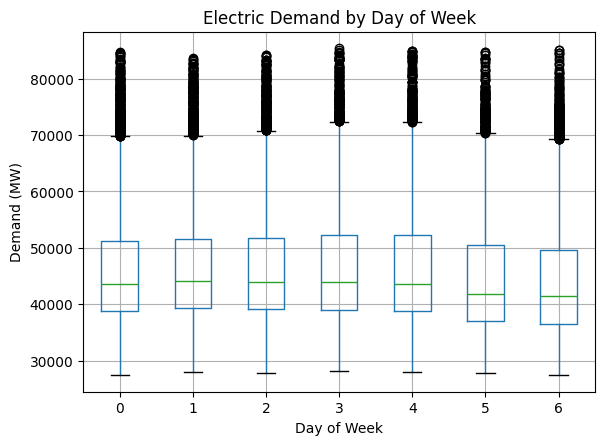

In [18]:
# Visualize the distribution of demand across different days of the week
plt.figure(figsize=(10,6))
df.boxplot(column='demand_MW', by='day_of_week')
plt.title('Electric Demand by Day of Week')
plt.suptitle('')
plt.xlabel('Day of Week')
plt.ylabel('Demand (MW)')
plt.show()

<Figure size 1000x600 with 0 Axes>

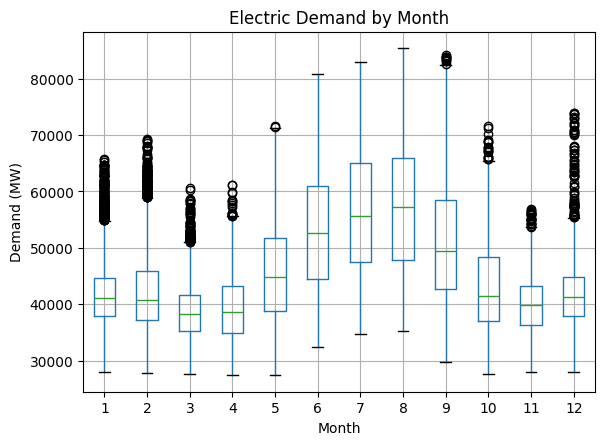

In [19]:
# Demand by Month Visualization
plt.figure(figsize=(10,6))
df.boxplot(column='demand_MW', by='month')
plt.title('Electric Demand by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Demand (MW)')
plt.show()
# Winter (December to February) - Moderate Demand
# Spring (March to May) - Moderate Demand but March & April has the least demand
# Summer (June to August) - Highest Demand 
# Fall (September to November) - Moderate Demand but October demand starts to decrease as we approach winter


In [20]:
season_map = {
    12:"winter",1:"winter",2:"winter",
    3:"spring",4:"spring",5:"spring",
    6:"summer",7:"summer",8:"summer",
    9:"fall",10:"fall",11:"fall"
}

df["season"] = df["month"].map(season_map)
df.sample(10)

,demand_MW,temperature,hour_of_day,day_of_week,time_of_day,month,is_weekend,season
timestamp,,,,,,,,
2022-01-06 13:00:00,46445.0,16.8,13,3,Afternoon,1,0,winter
2019-10-30 10:00:00,41952.0,21.6,10,2,Morning,10,0,fall
2023-05-25 12:00:00,53014.0,20.6,12,3,Afternoon,5,0,spring
2020-01-20 14:00:00,39529.0,5.7,14,0,Afternoon,1,0,winter
2021-08-13 16:00:00,69113.0,27.3,16,4,Afternoon,8,0,summer
2018-06-11 01:00:00,45581.0,29.5,1,0,Night,6,0,summer
2021-12-29 09:00:00,39364.0,22.1,9,2,Morning,12,0,winter
2019-03-23 17:00:00,35243.0,21.3,17,5,Afternoon,3,1,spring
2021-09-11 04:00:00,37875.0,21.9,4,5,Night,9,1,fall


<Figure size 1000x600 with 0 Axes>

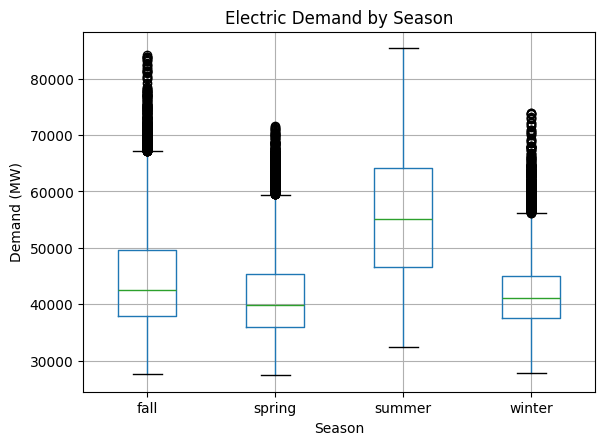

In [21]:
# Visualize the distribution of demand across different seasons
plt.figure(figsize=(10,6))
df.boxplot(column='demand_MW', by='season')
plt.title('Electric Demand by Season')
plt.suptitle('')
plt.xlabel('Season')
plt.ylabel('Demand (MW)')
plt.show()

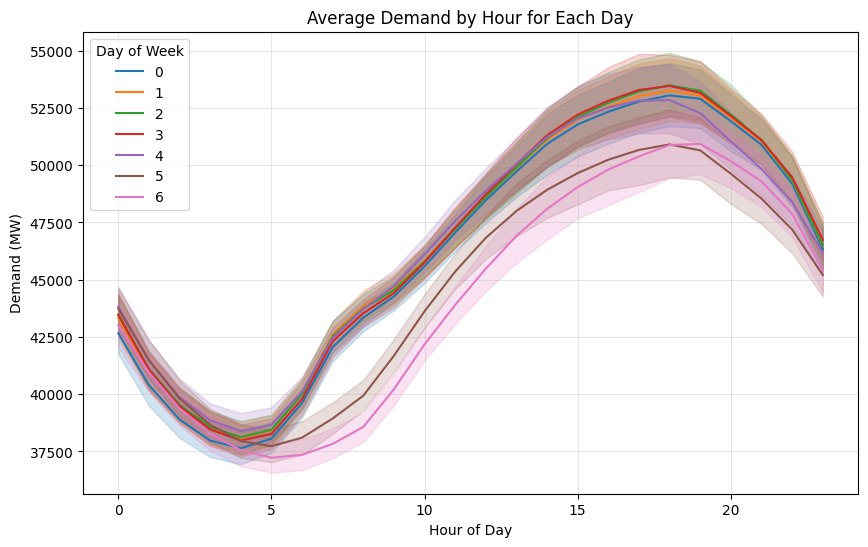

In [22]:
# Average demand by hour of the week Line Plot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x='hour_of_day',
    y='demand_MW',
    hue='day_of_week',
    estimator='mean',
    palette='tab10'
)

plt.title("Average Demand by Hour for Each Day")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (MW)")
plt.legend(title="Day of Week")

plt.grid(alpha=0.3)
plt.show()

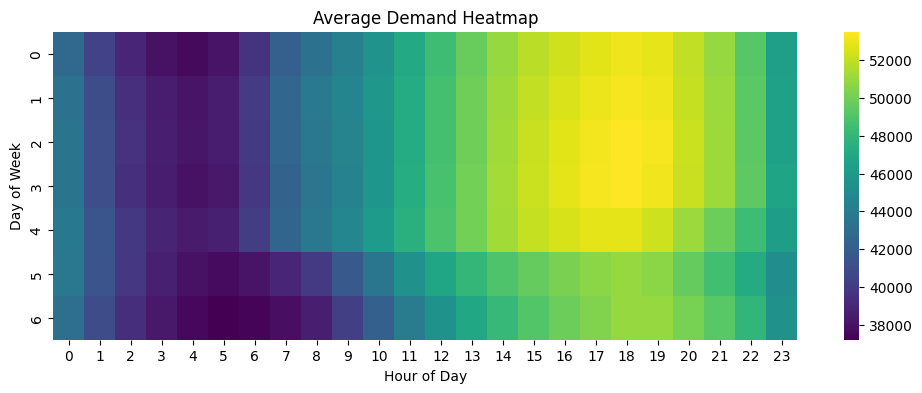

In [23]:
# Average demand by hour of the week - Heatmap

pivot = df.pivot_table(
    values='demand_MW',
    index='day_of_week',
    columns='hour_of_day',
    aggfunc='mean'
)

plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis')

plt.title("Average Demand Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

# Highest demand occurs during weekday evenings (5 PM to 9 PM) and lowest demand occurs during early morning hours (2 AM to 5 AM) across all days of the week.

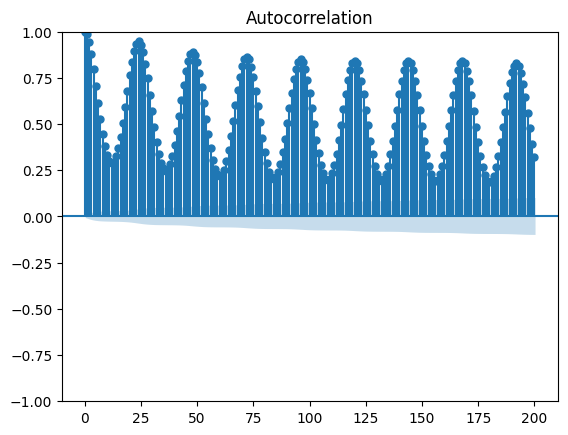

In [24]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots()
plot_acf(df['demand_MW'], lags=200, ax=ax)
plt.show()

# Electricity demand is strongly correlated with the demand 24 hours earlier.
# This indicates a strong daily seasonality in the data, where demand at a given hour is similar to the demand at the same hour on the previous day.
# The peaks are gradually decreasing, the further apart two points are in time, but the strong correlation at lag 24 suggests that the daily pattern is a key characteristic of the data.

In [25]:
# Creating Lag Features
lags = [24, 48, 168] # Lag features for the past 24 hours
for lag in lags:
    df[f'lag_{lag}'] = df['demand_MW'].shift(lag)
df.head(30)
# lag_24 is the demand 24 hours ago, and lag_168 is the demand 168 hours (1 week) ago.


,demand_MW,temperature,hour_of_day,day_of_week,time_of_day,month,is_weekend,season,lag_24,lag_48,lag_168
timestamp,,,,,,,,,,,
2018-01-01 00:00:00,50863.0,8.3,0,0,Night,1,0,winter,NaN,NaN,NaN
2018-01-01 01:00:00,50587.0,7.8,1,0,Night,1,0,winter,NaN,NaN,NaN
2018-01-01 02:00:00,50650.0,7.1,2,0,Night,1,0,winter,NaN,NaN,NaN
2018-01-01 03:00:00,50737.0,6.2,3,0,Night,1,0,winter,NaN,NaN,NaN
2018-01-01 04:00:00,51021.0,4.8,4,0,Night,1,0,winter,NaN,NaN,NaN
2018-01-01 05:00:00,51727.0,3.5,5,0,Night,1,0,winter,NaN,NaN,NaN
2018-01-01 06:00:00,52953.0,3.0,6,0,Morning,1,0,winter,NaN,NaN,NaN
2018-01-01 07:00:00,54315.0,2.8,7,0,Morning,1,0,winter,NaN,NaN,NaN
2018-01-01 08:00:00,55106.0,2.3,8,0,Morning,1,0,winter,NaN,NaN,NaN


In [26]:
# Creating Rolling Window Features
df['rolling_mean_3'] = df['demand_MW'].shift(1).rolling(window=3).mean()
df['rolling_mean_24'] = df['demand_MW'].shift(1).rolling(window=24).mean()
df['rolling_std_24'] = df['demand_MW'].shift(1).rolling(window=24).std()
df['rolling_mean_168'] = df['demand_MW'].shift(1).rolling(window=168).mean()
df.head(30)

,demand_MW,temperature,hour_of_day,day_of_week,time_of_day,month,is_weekend,season,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_24,rolling_std_24,rolling_mean_168
timestamp,,,,,,,,,,,,,,,
2018-01-01 00:00:00,50863.0,8.3,0,0,Night,1,0,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 01:00:00,50587.0,7.8,1,0,Night,1,0,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 02:00:00,50650.0,7.1,2,0,Night,1,0,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 03:00:00,50737.0,6.2,3,0,Night,1,0,winter,NaN,NaN,NaN,50700.000000,NaN,NaN,NaN
2018-01-01 04:00:00,51021.0,4.8,4,0,Night,1,0,winter,NaN,NaN,NaN,50658.000000,NaN,NaN,NaN
2018-01-01 05:00:00,51727.0,3.5,5,0,Night,1,0,winter,NaN,NaN,NaN,50802.666667,NaN,NaN,NaN
2018-01-01 06:00:00,52953.0,3.0,6,0,Morning,1,0,winter,NaN,NaN,NaN,51161.666667,NaN,NaN,NaN
2018-01-01 07:00:00,54315.0,2.8,7,0,Morning,1,0,winter,NaN,NaN,NaN,51900.333333,NaN,NaN,NaN
2018-01-01 08:00:00,55106.0,2.3,8,0,Morning,1,0,winter,NaN,NaN,NaN,52998.333333,NaN,NaN,NaN


In [27]:
# Creating Weather Lag Features
df['temp_lag_1'] = df['temperature'].shift(1)
df['temp_lag_3'] = df['temperature'].shift(3)
df['temp_lag_24'] = df['temperature'].shift(24)
df.head(30)


,demand_MW,temperature,hour_of_day,day_of_week,time_of_day,month,is_weekend,season,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_24,rolling_std_24,rolling_mean_168,temp_lag_1,temp_lag_3,temp_lag_24
timestamp,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,50863.0,8.3,0,0,Night,1,0,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 01:00:00,50587.0,7.8,1,0,Night,1,0,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.3,NaN,NaN
2018-01-01 02:00:00,50650.0,7.1,2,0,Night,1,0,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.8,NaN,NaN
2018-01-01 03:00:00,50737.0,6.2,3,0,Night,1,0,winter,NaN,NaN,NaN,50700.000000,NaN,NaN,NaN,7.1,8.3,NaN
2018-01-01 04:00:00,51021.0,4.8,4,0,Night,1,0,winter,NaN,NaN,NaN,50658.000000,NaN,NaN,NaN,6.2,7.8,NaN
2018-01-01 05:00:00,51727.0,3.5,5,0,Night,1,0,winter,NaN,NaN,NaN,50802.666667,NaN,NaN,NaN,4.8,7.1,NaN
2018-01-01 06:00:00,52953.0,3.0,6,0,Morning,1,0,winter,NaN,NaN,NaN,51161.666667,NaN,NaN,NaN,3.5,6.2,NaN
2018-01-01 07:00:00,54315.0,2.8,7,0,Morning,1,0,winter,NaN,NaN,NaN,51900.333333,NaN,NaN,NaN,3.0,4.8,NaN
2018-01-01 08:00:00,55106.0,2.3,8,0,Morning,1,0,winter,NaN,NaN,NaN,52998.333333,NaN,NaN,NaN,2.8,3.5,NaN


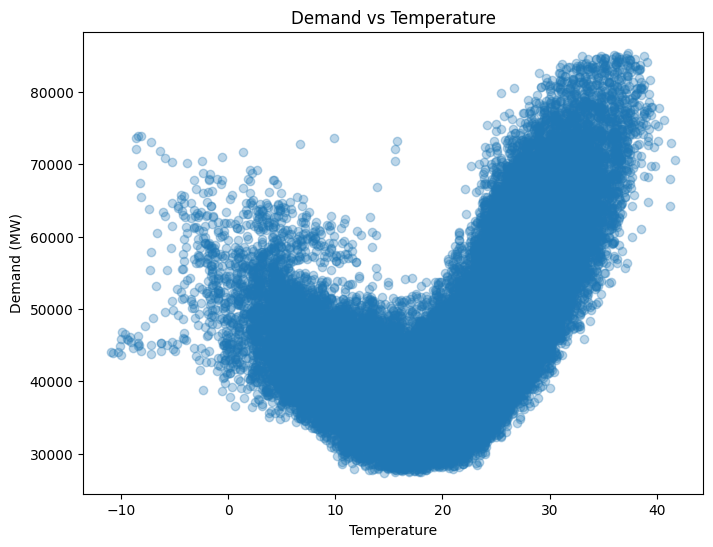

In [28]:
# Temperature vs Demand Visualization
plt.figure(figsize=(8,6))
plt.scatter(df['temperature'], df['demand_MW'], alpha=0.3)
plt.xlabel('Temperature')
plt.ylabel('Demand (MW)')
plt.title('Demand vs Temperature')
plt.show()
# Higher temperatures are associated with higher demand, likely due to increased use of air conditioning during hot weather. 
# There is a clear positive correlation between temperature and electric demand, especially at higher temperatures.
# Lower temperatures also show increased demand, likely due to heating needs during cold weather, but the correlation is not as strong as with high temperatures.

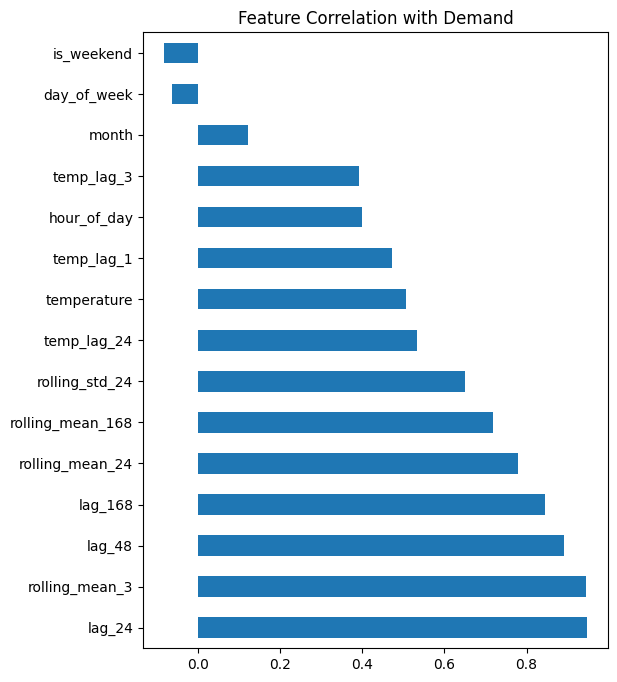

In [29]:
# Correlation 
numeric_df = df.select_dtypes(include=['number'])
corr_target = numeric_df.corr()['demand_MW'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
corr_target.drop('demand_MW').plot(kind='barh')
plt.title("Feature Correlation with Demand")
plt.show()

After exploratory analysis, raw time-based features are transformed
into cyclical representations to better capture periodic patterns.
The original variables are then removed to avoid redundancy.

In [30]:
# Cyclical Encoding of time-based features
# Hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# Day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Droping original values
df.drop(columns=["hour_of_day", "day_of_week", "month"], inplace=True)

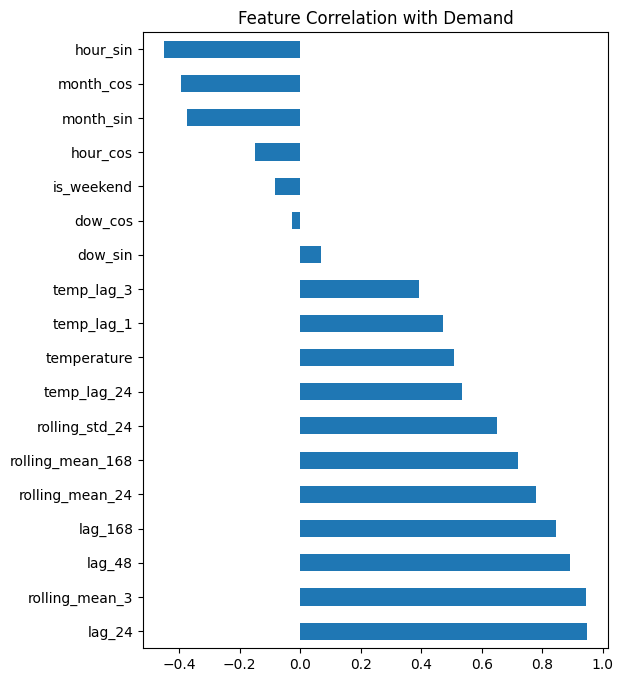

In [31]:
# Correlation again with cyclical features
numeric_df = df.select_dtypes(include=['number'])
corr_target = numeric_df.corr()['demand_MW'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
corr_target.drop('demand_MW').plot(kind='barh')
plt.title("Feature Correlation with Demand")
plt.show()

In [32]:
df.isna().sum()
# lot of missing values in the lag and rolling features due to the shifting and rolling operations. 
# We will need to handle these missing values before modeling, either by dropping them or using imputation techniques.
# Since the number of missing values is relatively small compared to the overall dataset, we can choose to drop these rows for simplicity.

demand_MW             0
temperature           0
time_of_day           0
is_weekend            0
season                0
lag_24               24
lag_48               48
lag_168             168
rolling_mean_3        3
rolling_mean_24      24
rolling_std_24       24
rolling_mean_168    168
temp_lag_1            1
temp_lag_3            3
temp_lag_24          24
hour_sin              0
hour_cos              0
dow_sin               0
dow_cos               0
month_sin             0
month_cos             0
dtype: int64

In [33]:
df = df.dropna()

In [34]:
df.isna().sum() # No missing values remain after dropping rows with NaNs.

demand_MW           0
temperature         0
time_of_day         0
is_weekend          0
season              0
lag_24              0
lag_48              0
lag_168             0
rolling_mean_3      0
rolling_mean_24     0
rolling_std_24      0
rolling_mean_168    0
temp_lag_1          0
temp_lag_3          0
temp_lag_24         0
hour_sin            0
hour_cos            0
dow_sin             0
dow_cos             0
month_sin           0
month_cos           0
dtype: int64

In [35]:
# Save the processed dataset for modeling
df.to_csv("../data/processed/features_dataset.csv", index=True)